WHAT ARE THE MOST DEMANDED SKILLS FOR TOP 3 MOST POPULAR DATA ROLES?

Methodology

 1. Clean-up
 2. Calculate skill count based on job_title_short
 3. Calculate skill percentage
 4. Plot final findings

 

In [2]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)



In [3]:
df_VN = df[df['job_country']=='Vietnam']

In [4]:
df_skills = df_VN.explode('job_skills')
df_skills[['job_title','job_skills']]

,job_title,job_skills
1203,"Expert, Data Engineering (40000062)",sql
1203,"Expert, Data Engineering (40000062)",nosql
1203,"Expert, Data Engineering (40000062)",python
1203,"Expert, Data Engineering (40000062)",r
1203,"Expert, Data Engineering (40000062)",scala
...,...,...
785609,Data Engineer,nosql
785609,Data Engineer,postgresql
785609,Data Engineer,mysql
785609,Data Engineer,spark


In [5]:
df_skills_count = df_skills.groupby(['job_skills','job_title_short']).size() # series need to be converted to dataframe

df_skills_count = df_skills_count.reset_index(name='skill_count')

df_skills_count.sort_values(by = 'skill_count',ascending = False, inplace = True)


In [6]:
df_skills_count

,job_skills,job_title_short,skill_count
719,sql,Data Engineer,477
550,python,Data Engineer,468
692,spark,Data Engineer,282
301,java,Data Engineer,231
551,python,Data Scientist,230
...,...,...,...
815,watson,Data Engineer,1
271,graphql,Data Analyst,1
273,graphql,Machine Learning Engineer,1
30,atlassian,Senior Data Engineer,1


In [7]:
job_titles = df_skills_count['job_title_short'].unique().tolist()

job_titles = sorted(job_titles[:3]) #sorted() là sort theo bảng alphabet

job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

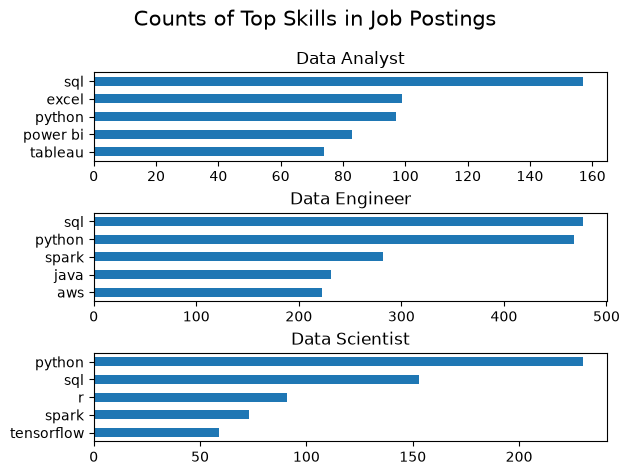

In [8]:
fig,ax =plt.subplots(len(job_titles),1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    df_plot.plot(kind = 'barh', x ='job_skills',y='skill_count',ax=ax[i],title=job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)

fig.suptitle('Counts of Top Skills in Job Postings',fontsize =15)
fig.tight_layout(h_pad = 0.5)
plt.show()

In [9]:
df_VN = df[df['job_location'] == 'Vietnam']
df_job_title_count = df_VN['job_title_short'].value_counts().head().reset_index(name='jobs_total')


In [10]:
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, how='left', on='job_title_short')  # merge 2 dataframe to get the total number of jobs for each job title, same logic with SQL

df_skills_perc['skills_percent'] =100* df_skills_perc['skill_count'] / df_skills_perc['jobs_total']

df_skills_perc 

,job_skills,job_title_short,skill_count,jobs_total,skills_percent
0,sql,Data Engineer,477,103.0,463.106796
1,python,Data Engineer,468,103.0,454.368932
2,spark,Data Engineer,282,103.0,273.786408
3,java,Data Engineer,231,103.0,224.271845
4,python,Data Scientist,230,48.0,479.166667
...,...,...,...,...,...
834,watson,Data Engineer,1,103.0,0.970874
835,graphql,Data Analyst,1,91.0,1.098901
836,graphql,Machine Learning Engineer,1,NaN,NaN
837,atlassian,Senior Data Engineer,1,NaN,NaN


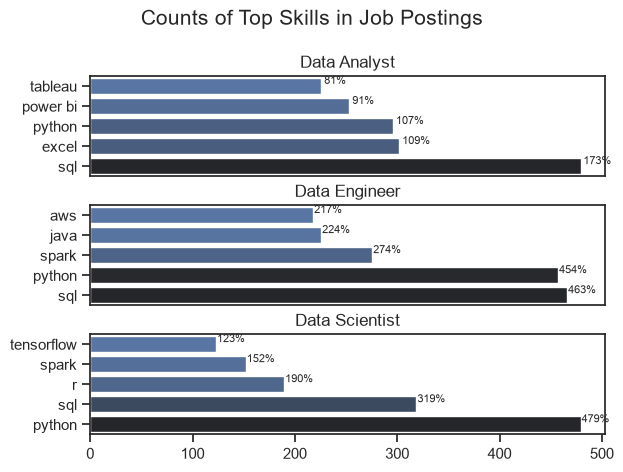

In [27]:
fig,ax =plt.subplots(len(job_titles),1)

sns.set_theme(style ='ticks')  # Set the theme of the plot

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    #df_plot.plot(kind = 'barh', x ='job_skills',y='skills_percent',ax=ax[i],title=job_title)
    sns.barplot(data=df_plot, x='skills_percent', y='job_skills', ax=ax[i],hue = 'skill_count',palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].legend().set_visible(False)
    ax[1].set_xlim(0,500)

    for n ,v in enumerate(df_plot['skills_percent']):
        ax[i].text(v + 1,n+.25, f'{v:.0f}%', fontsize =8, va='center')

    if i != len(job_titles)-1:
        ax[i].set_xticks([])
        
fig.suptitle('Counts of Top Skills in Job Postings',fontsize =15)
fig.tight_layout(h_pad = 0.5)
plt.show()